### Import all the libraries and set up all the requirements that you will need

In [366]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import plot_tree
from scipy.stats import shapiro
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import randint

### Read the train and test data sets, and check for the datatypes.

In [113]:
df_train = pd.read_csv("train.csv")

In [7]:
df_test = pd.read_csv("test.csv")

In [8]:
df_test.shape

(50000, 27)

In [9]:
df_train.shape

(100000, 28)

### Combining Train and Test dataset

In [11]:
df_test['Credit_Score'] = np.nan
df_train['is_train'] = 1
df_test['is_train'] = 0

In [12]:
combined = pd.concat([df_train, df_test], ignore_index=True)

In [13]:
combined.shape

(150000, 29)

In [14]:
# Split back again 
#train_cleanddd = combined[combined.is_train==1].drop('is_train', axis=1)
#test_cleanddd = combined[combined.is_train==0].drop('is_train', axis=1)

### Fix the problem that the features have been wrongly identified.

### ● Clean the anomalies in the categorical variables. A few anomalies have been mentioned here

In [17]:
occupation_miss= combined["Occupation"][combined["Occupation"]=="_______"].count()
ssn_miss = combined["SSN"][combined["SSN"]=="#F%$D@*&8"].count()
pb_miss = combined["Payment_Behaviour"][combined["Payment_Behaviour"]=="!@9#%8"].count()
print("Anomalies in occupation are:",occupation_miss)
print("Anomalies in SSN are :",ssn_miss)
print("Anomalies in Payment behaviour are :",pb_miss)

Anomalies in occupation are: 10500
Anomalies in SSN are : 8400
Anomalies in Payment behaviour are : 11400


In [18]:
# Get the customer_id's mode value for the below 3 colums 

occupation_mode = combined.groupby("Customer_ID")["Occupation"].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan)
ssn_mode = combined.groupby("Customer_ID")["SSN"].agg(lambda x : x.mode()[0] if len(x.mode()) > 0 else np.nam)
pb_mode = combined.groupby("Customer_ID")["Payment_Behaviour"].agg(lambda x:x.mode()[0] if len(x.mode()) > 0 else np.nan)

In [19]:
# Replace the missing values or anamolies with the customer mode of that column

combined.loc[combined["Occupation"]=="_______","Occupation"]= combined["Customer_ID"].map(occupation_mode)
combined.loc[combined["SSN"]=="#F%$D@*&8","SSN"]= combined["Customer_ID"].map(ssn_mode)
combined.loc[combined["Payment_Behaviour"]=="!@9#%8","Payment_Behaviour"]= combined["Customer_ID"].map(pb_mode)

In [20]:
occupation_fill = combined["Occupation"][combined["Occupation"]=="_______"].count()
ssn_fill = combined["SSN"][combined["SSN"]=="#F%$D@*&8"].count()
pb_fill = combined["Payment_Behaviour"][combined["Payment_Behaviour"]=="!@9#%8"].count()
print("Number of anomalies in occupation after replacing :",occupation_fill)
print("Number of anomalies in SSN after replacing :", ssn_fill)
print("Number of anomalies in payment behaviour agter replacing :", pb_fill)

Number of anomalies in occupation after replacing : 0
Number of anomalies in SSN after replacing : 6
Number of anomalies in payment behaviour agter replacing : 1345


In [21]:
wrong_ssn = "#F%$D@*&8"
wrong_pb = "!@9#%8"

In [22]:
print("remaining wrong ssn :", (combined["SSN"]==wrong_ssn).sum())
print("remaining wrong pb :", (combined["Payment_Behaviour"]==wrong_pb).sum())

remaining wrong ssn : 6
remaining wrong pb : 1345


In [23]:
combined = combined[(combined["SSN"]!= wrong_ssn) & (combined["Payment_Behaviour"]!=wrong_pb)]

In [24]:
occupation_fill = combined["Occupation"][combined["Occupation"]=="_______"].count()
ssn_fill = combined["SSN"][combined["SSN"]=="#F%$D@*&8"].count()
pb_fill = combined["Payment_Behaviour"][combined["Payment_Behaviour"]=="!@9#%8"].count()
print("Number of anomalies in occupation after replacing :",occupation_fill)
print("Number of anomalies in SSN agter replacing :", ssn_fill)
print("Number of anomalies in payment behaviour agter replacing :", pb_fill)

Number of anomalies in occupation after replacing : 0
Number of anomalies in SSN agter replacing : 0
Number of anomalies in payment behaviour agter replacing : 0


### ● Clean the anomalies for numerical variables

In [26]:
# Age, Num_of_loans, Annual_Income, Num_of_Delayed_Payment,Changed_Credit_Limit,Outstanding_Debt,Amount_invested_monthly,Monthly_Balance, 

combined["Age"] = (combined["Age"].astype(str).str.extract(r"(\d+)")[0].astype(int))
combined["Num_of_Loan"] = (combined["Num_of_Loan"].astype(str).str.extract(r"(\d+)")[0].astype(int))
combined["Annual_Income"] = (combined["Annual_Income"].astype(str).str.extract(r"(\d+)")[0].astype(int))
combined["Num_of_Delayed_Payment"]=(combined["Num_of_Delayed_Payment"].astype(str).str.extract(r"(\d+)")[0].astype(float))
combined["Changed_Credit_Limit"] = (combined["Changed_Credit_Limit"].astype(str).str.extract(r"(\d+)")[0].astype(float))
combined["Outstanding_Debt"] = (combined["Outstanding_Debt"].astype(str).str.extract(r"(\d+)")[0].astype(float))
combined["Amount_invested_monthly"] = (combined["Amount_invested_monthly"].astype(str).str.extract(r"(\d+)")[0].astype(float))
combined["Monthly_Balance"] = (combined["Monthly_Balance"].astype(str).str.extract(r"(\d+)")[0].astype(float))

In [27]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148649 entries, 0 to 149999
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        148649 non-null  object 
 1   Customer_ID               148649 non-null  object 
 2   Month                     148649 non-null  object 
 3   Name                      133756 non-null  object 
 4   Age                       148649 non-null  int32  
 5   SSN                       148649 non-null  object 
 6   Occupation                148649 non-null  object 
 7   Annual_Income             148649 non-null  int32  
 8   Monthly_Inhand_Salary     126349 non-null  float64
 9   Num_Bank_Accounts         148649 non-null  int64  
 10  Num_Credit_Card           148649 non-null  int64  
 11  Interest_Rate             148649 non-null  int64  
 12  Num_of_Loan               148649 non-null  int32  
 13  Type_of_Loan              131699 non-null  object

In [28]:
combined["Age"][combined["Age"] >= 85].count()

4143

In [29]:
abnormal_age = combined["Age"] > 85

In [30]:
# Get the customer_id's median age value for the below columns 

age_median = combined.groupby("Customer_ID")["Age"].median()

In [31]:
# map each row's Customer_ID to its median Age

median_for_rows = combined["Customer_ID"].map(age_median)

In [115]:
# only replace where Age is abnormal

combined.loc[abnormal_age,"Age"] = median_for_rows[abnormal_age]

In [33]:
combined["Age"][combined["Age"]>85]

Series([], Name: Age, dtype: float64)

In [34]:
# Check if we have nay negative values in numeric columns

num_col = combined.select_dtypes([int,float]) 

neg_val = (num_col<0).any()
neg_val = neg_val[neg_val]
neg_val

Num_Bank_Accounts      True
Delay_from_due_date    True
dtype: bool

### Convert the Credit_History_Age datatype variable into float data types by taking only year and month.

#### Example. 22 years and 1 month → 22.1

In [37]:
# Convert the Credit_History_Age datatype variable into float data types by taking only year and month. Example. 22 years and 1 month → 22.1.

s = combined["Credit_History_Age"].astype(str).str.lower()

years = s.str.extract(r"(\d+)\s*year")[0].astype(float)
month = s.str.extract(r"(\d+)\s*month")[0].astype(float)
years = years.fillna(0)
month = month.fillna(0)

combined["Credit_History_Age"] = (years+month/100)

In [38]:
combined["Payment_of_Min_Amount"][combined["Payment_of_Min_Amount"]=="NM"].count()

17835

#### Change the month's names into its number

In [40]:
# Changing the months name into number

combined["Month"].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [41]:
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 'July':7,
       'August':8, 'September':9, 'October':10, 'November':11, 'December':12}

In [42]:
combined["Month"] = combined["Month"].map(month_map)

In [43]:
combined["Month"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int64)

### Handling missing values in a dataframe

In [45]:
miss_value = combined.isnull().sum() [combined.isnull().sum() > 0]
miss_value

Name                       14893
Monthly_Inhand_Salary      22300
Type_of_Loan               16950
Num_of_Delayed_Payment     10392
Changed_Credit_Limit        3126
Num_Credit_Inquiries        2966
Amount_invested_monthly     6689
Monthly_Balance             1740
Credit_Score               49554
dtype: int64

In [46]:
combined_miss_values = combined[["Name","Monthly_Inhand_Salary","Type_of_Loan","Num_of_Delayed_Payment","Changed_Credit_Limit","Num_Credit_Inquiries",
"Amount_invested_monthly","Monthly_Balance","Credit_Score"]]

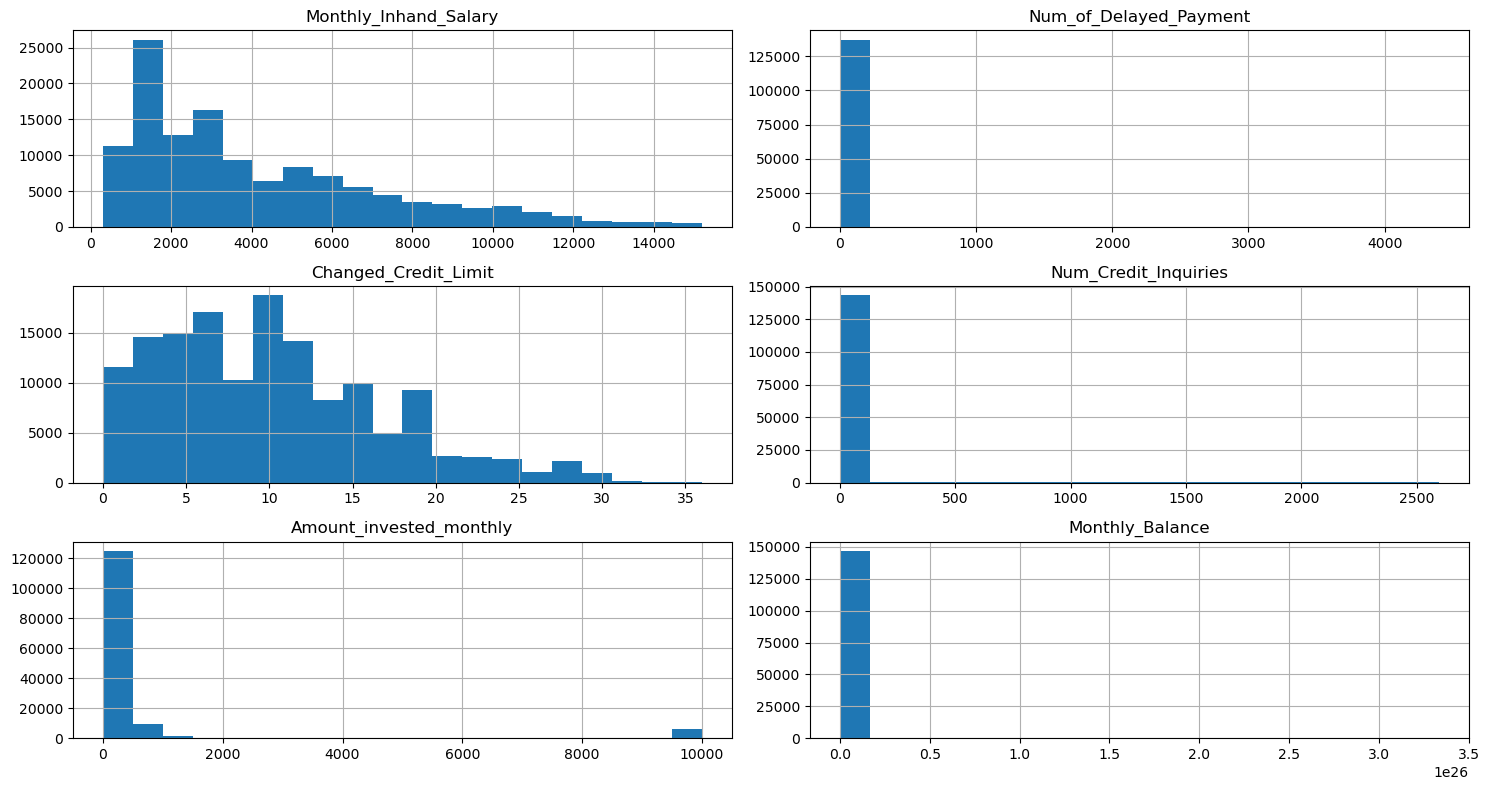

In [47]:
combined_miss_values.hist(bins=20,figsize=(15,8))
plt.tight_layout()
plt.show()

#### We can go with the median for all the numeric colums as all of them are skewed distribution and not a normal distribution

##### Numeric Columns

In [50]:
Monthly_Inhand_Salary_median = combined.groupby("Customer_ID")["Monthly_Inhand_Salary"].median()
Num_of_Delayed_Payment_median = combined.groupby("Customer_ID")["Num_of_Delayed_Payment"].median()
Changed_Credit_Limit_median = combined.groupby("Customer_ID")["Changed_Credit_Limit"].median()
Num_Credit_Inquiries_median = combined.groupby("Customer_ID")["Num_Credit_Inquiries"].median()
Amount_invested_monthly_median = combined.groupby("Customer_ID")["Amount_invested_monthly"].median()
Monthly_Balance_median = combined.groupby("Customer_ID")["Monthly_Balance"].median()

##### Categorical columns

In [52]:
Name_mode = combined.groupby("Customer_ID")["Name"].agg(lambda x:x.mode()[0] if len(x.mode()) > 0 else np.nan)
Type_of_Loan_mode = combined.groupby("Customer_ID")["Type_of_Loan"].agg(lambda x : x.mode()[0] if len(x.mode()) > 0 else np.nan)

#### For all missing values fill with median values of each customer for numeric columns and mode value of each customer for categorical columns

In [54]:
combined["Monthly_Inhand_Salary"] = combined["Monthly_Inhand_Salary"].fillna(combined["Customer_ID"].map(Monthly_Inhand_Salary_median))
combined["Num_of_Delayed_Payment"] = combined["Num_of_Delayed_Payment"].fillna(combined["Customer_ID"].map(Num_of_Delayed_Payment_median))
combined["Changed_Credit_Limit"] = combined["Changed_Credit_Limit"].fillna(combined["Customer_ID"].map(Changed_Credit_Limit_median))
combined["Num_Credit_Inquiries"] = combined["Num_Credit_Inquiries"].fillna(combined["Customer_ID"].map(Num_Credit_Inquiries_median))
combined["Amount_invested_monthly"] = combined["Amount_invested_monthly"].fillna(combined["Customer_ID"].map(Amount_invested_monthly_median))
combined["Monthly_Balance"] = combined["Monthly_Balance"].fillna(combined["Customer_ID"].map(Monthly_Balance_median))
combined["Name"] = combined["Name"].fillna(combined["Customer_ID"].map(Name_mode))
combined["Type_of_Loan"] = combined["Type_of_Loan"].fillna(combined["Customer_ID"].map(Type_of_Loan_mode))

### Perform Univariate, Bivariate, and Multivariate analyses to find the factors that affect the Target variables

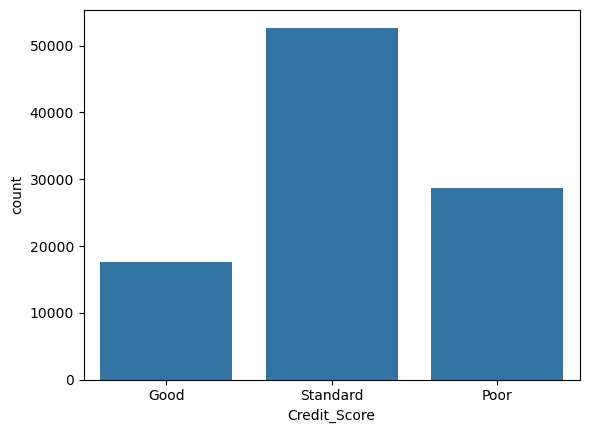

In [56]:
# Count of credit score variables in train data set

sns.countplot(data=combined[combined["is_train"]==1], x="Credit_Score")
plt.show()

In [57]:
numeric_corr = combined.corr(numeric_only=True)
numeric_corr

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,is_train
Month,1.000000,0.025939,-0.003721,-0.002455,-0.003178,0.002211,-0.002743,0.002529,-0.000295,-0.002366,-0.000412,6.838528e-03,-0.000004,9.657548e-04,0.028647,0.004624,0.000476,0.001841,-0.819410
Age,0.025939,1.000000,0.004387,0.090999,-0.004793,-0.005045,-0.000920,-0.009413,-0.174464,-0.000038,-0.157565,-3.892498e-03,-0.202752,2.846403e-02,0.188254,0.000500,0.007005,0.002350,-0.021215
Annual_Income,-0.003721,0.004387,1.000000,0.030108,-0.002984,0.000697,-0.001293,0.003018,-0.009373,0.000564,-0.001217,2.185120e-03,-0.005295,6.733833e-03,0.000262,-0.000915,-0.001271,-0.000834,0.003538
Monthly_Inhand_Salary,-0.002455,0.090999,0.030108,1.000000,-0.010743,-0.004726,-0.008269,-0.010277,-0.249826,-0.002544,-0.176036,-7.838362e-03,-0.269175,1.729818e-01,0.218484,0.010611,0.059722,0.001721,0.001898
Num_Bank_Accounts,-0.003178,-0.004793,-0.002984,-0.010743,1.000000,0.001482,-0.001837,-0.001039,0.017091,-0.002176,0.008517,-3.569109e-04,0.015309,-3.275535e-03,-0.008034,0.000064,0.000005,-0.001105,0.000602
Num_Credit_Card,0.002211,-0.005045,0.000697,-0.004726,0.001482,1.000000,-0.002497,0.000107,0.009103,0.001467,0.005248,-2.302343e-03,0.006155,-2.085992e-03,-0.006190,0.002480,-0.005885,-0.001350,-0.001494
Interest_Rate,-0.002743,-0.000920,-0.001293,-0.008269,-0.001837,-0.002497,1.000000,0.001742,0.011164,0.002660,0.003927,-2.702553e-03,0.009765,-1.350082e-03,-0.008113,0.002912,-0.001549,-0.001305,0.004004
Num_of_Loan,0.002529,-0.009413,0.003018,-0.010277,-0.001039,0.000107,0.001742,1.000000,0.014462,0.005755,0.012020,-5.224491e-04,0.022219,-5.460438e-03,-0.014865,-0.002404,0.001888,-0.001255,-0.003832
Delay_from_due_date,-0.000295,-0.174464,-0.009373,-0.249826,0.017091,0.009103,0.011164,0.014462,1.000000,0.016020,0.297209,8.541741e-03,0.571672,-6.574971e-02,-0.392322,-0.001485,-0.011705,-0.003252,0.000440
Num_of_Delayed_Payment,-0.002366,-0.000038,0.000564,-0.002544,-0.002176,0.001467,0.002660,0.005755,0.016020,1.000000,0.010284,-8.157380e-04,0.011998,-2.718759e-04,-0.010545,-0.000159,-0.000716,-0.000912,0.000422


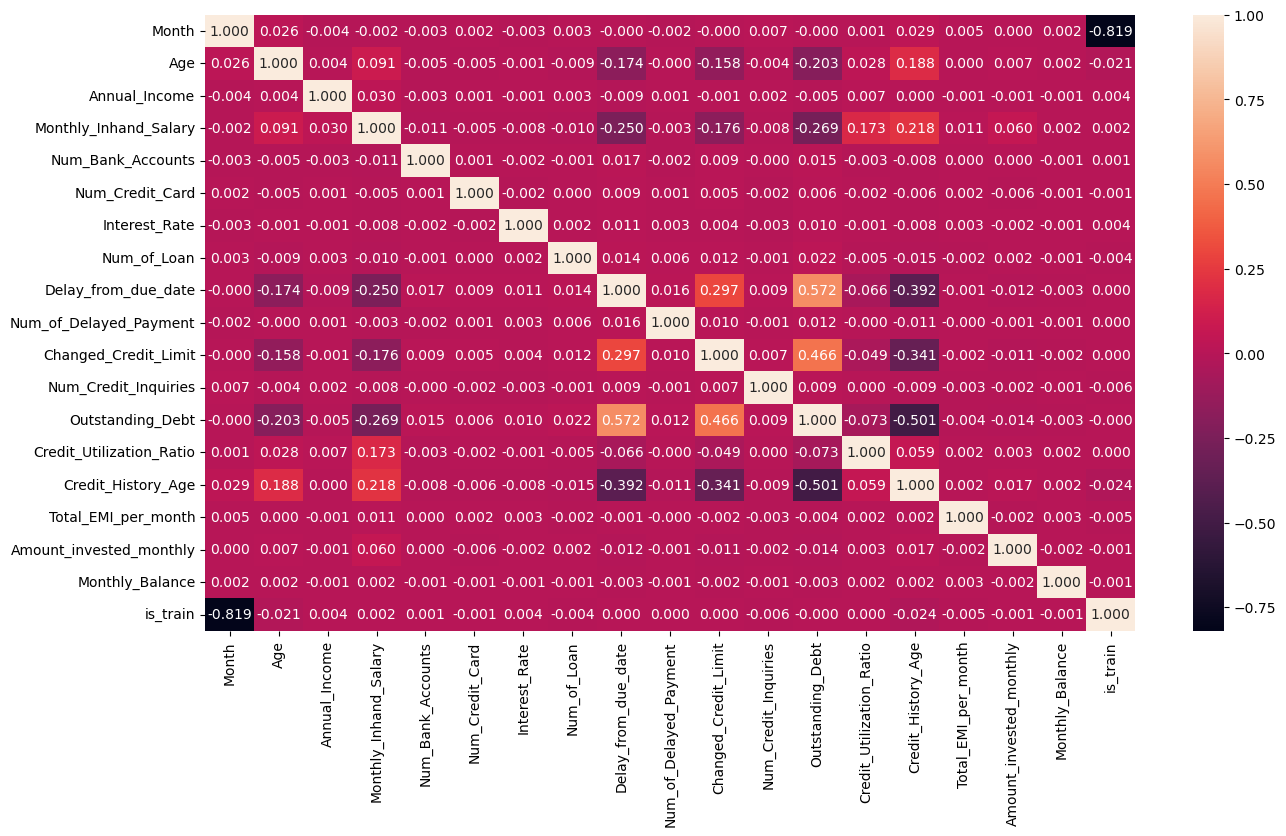

In [58]:
plt.figure(figsize=(15,8))
sns.heatmap(numeric_corr,annot=True,fmt=".3f")
plt.show()

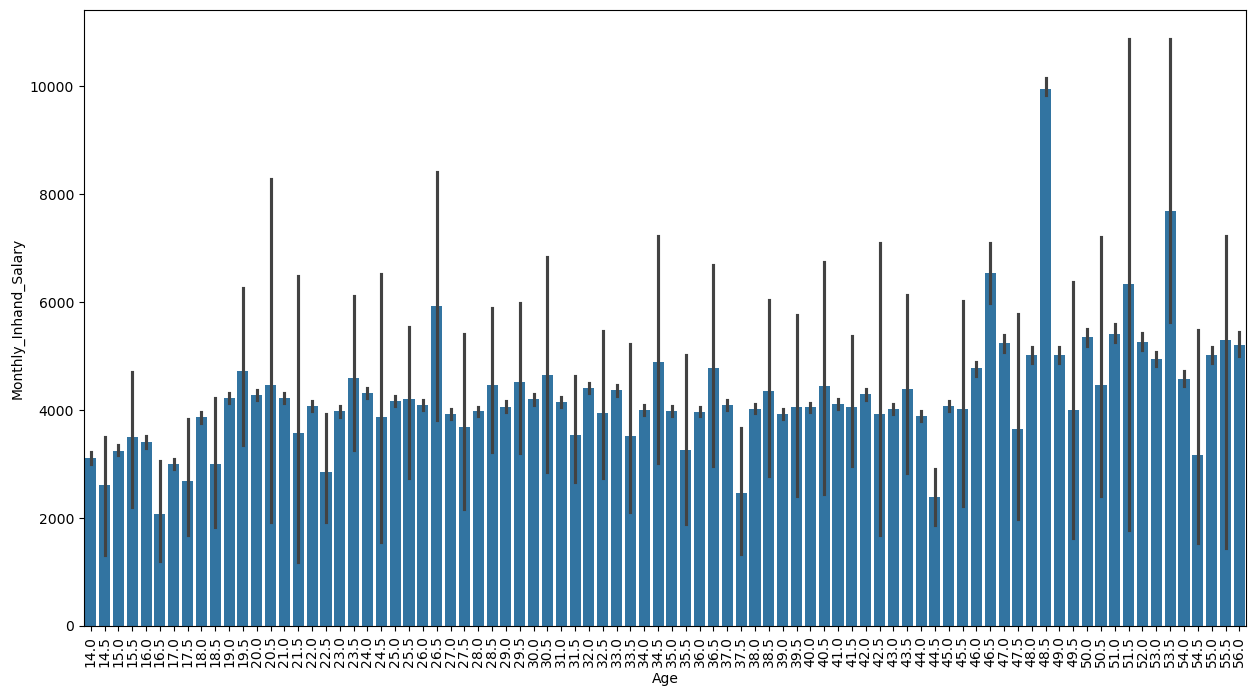

In [59]:
plt.figure(figsize=(15,8))
sns.barplot(data=combined,x="Age",y="Monthly_Inhand_Salary",estimator=np.mean)
plt.xticks(rotation=90)
plt.show()

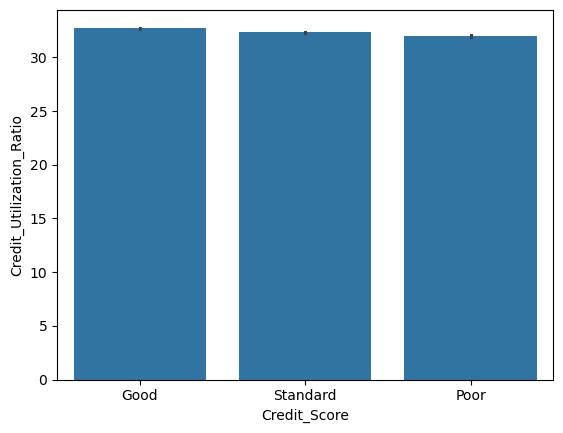

In [60]:
sns.barplot(data=combined,x="Credit_Score",y="Credit_Utilization_Ratio")
plt.show()

In [61]:
combined.shape

(148649, 29)

### Splitting only train dataset from the above combined datasets

In [63]:
# Unmerging the Train and Test data files which was merged to clean the data

train_clean = combined[combined.is_train==1].drop('is_train', axis=1)
test_clean = combined[combined.is_train==0].drop('is_train', axis=1)

In [64]:
train_clean.shape

(99095, 28)

In [65]:
train_clean.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,1,Aaron Maashoh,23.0,821-00-0265,Scientist,19114,1824.843333,3,...,_,809.0,26.822620,22.01,No,49.574949,80.0,High_spent_Small_value_payments,312.0,Good
1,0x1603,CUS_0xd40,2,Aaron Maashoh,23.0,821-00-0265,Scientist,19114,1824.843333,3,...,Good,809.0,31.944960,0.00,No,49.574949,118.0,Low_spent_Large_value_payments,284.0,Good
2,0x1604,CUS_0xd40,3,Aaron Maashoh,23.0,821-00-0265,Scientist,19114,1824.843333,3,...,Good,809.0,28.609352,22.03,No,49.574949,81.0,Low_spent_Medium_value_payments,331.0,Good
3,0x1605,CUS_0xd40,4,Aaron Maashoh,23.0,821-00-0265,Scientist,19114,1824.843333,3,...,Good,809.0,31.377862,22.04,No,49.574949,199.0,Low_spent_Small_value_payments,223.0,Good
4,0x1606,CUS_0xd40,5,Aaron Maashoh,23.0,821-00-0265,Scientist,19114,1824.843333,3,...,Good,809.0,24.797347,22.05,No,49.574949,41.0,High_spent_Medium_value_payments,341.0,Good


### Encode the categorical variables with related technologies. Change the target variable classes as (poor to 0, Standard to 1, Good to 2).

In [67]:
encode_cs = {'Poor':0,'Standard':1,'Good':2}
encode_cs

{'Poor': 0, 'Standard': 1, 'Good': 2}

In [68]:
train_clean["Credit_Score_encoded"] = train_clean["Credit_Score"].map(encode_cs)
print(train_clean["Credit_Score_encoded"].value_counts().sort_index())

Credit_Score_encoded
0    28753
1    52711
2    17631
Name: count, dtype: int64


### Encode categoricals and Scale numerics

In [70]:
numeric_col = train_clean.select_dtypes(include='number').columns
numeric_col = [col for col in numeric_col if col != "Credit_Score_encoded"]

In [71]:
len(numeric_col)

18

In [72]:
std_scaler = StandardScaler()
train_clean[numeric_col] = std_scaler.fit_transform(train_clean[numeric_col])

#### Removing high cardinality columns

In [74]:
train_clean_1 = train_clean.drop(columns=["Customer_ID","Name","ID","SSN","Type_of_Loan","Credit_Score"])

In [75]:
train_clean_1.shape

(99095, 23)

In [76]:
train_clean_1.columns

Index(['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score_encoded'],
      dtype='object')

In [77]:
trial_ob = train_clean_1.select_dtypes(include=['object']).columns

In [78]:
obj_columns = train_clean_1.select_dtypes(include=['object'])

In [79]:
obj_columns = list(map(str,obj_columns))

In [80]:
train_dummies = pd.get_dummies(train_clean_1,columns=obj_columns,prefix='D_')

In [81]:
train_dummies.head()

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,D___,D__NM,D__No,D__Yes,D__High_spent_Large_value_payments,D__High_spent_Medium_value_payments,D__High_spent_Small_value_payments,D__Low_spent_Large_value_payments,D__Low_spent_Medium_value_payments,D__Low_spent_Small_value_payments
0,-1.527639,-0.958739,-0.110102,-0.743623,-0.119953,-0.143229,-0.148811,-0.109298,-1.216206,-0.104310,...,True,False,True,False,False,False,True,False,False,False
1,-1.091190,-0.958739,-0.110102,-0.743623,-0.119953,-0.143229,-0.148811,-0.109298,-1.485201,-0.106602,...,False,False,True,False,False,False,False,True,False,False
2,-0.654741,-0.958739,-0.110102,-0.743623,-0.119953,-0.143229,-0.148811,-0.109298,-1.216206,-0.104310,...,False,False,True,False,False,False,False,False,True,False
3,-0.218293,-0.958739,-0.110102,-0.743623,-0.119953,-0.143229,-0.148811,-0.109298,-1.081708,-0.118062,...,False,False,True,False,False,False,False,False,False,True
4,0.218156,-0.958739,-0.110102,-0.743623,-0.119953,-0.143229,-0.148811,-0.109298,-1.014459,-0.106602,...,False,False,True,False,False,True,False,False,False,False


In [82]:
# Splitting the clean train dataset into train test split 

X = train_dummies.drop(columns="Credit_Score_encoded")
y = train_dummies["Credit_Score_encoded"]


X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.3)

In [83]:
train_clean["Credit_Score"].unique()

array(['Good', 'Standard', 'Poor'], dtype=object)

In [84]:
cs_g = train_clean[train_clean["Credit_Score"]=="Good"]["Annual_Income"]
cs_s = train_clean[train_clean["Credit_Score"]=="Standard"]["Annual_Income"]
cs_p = train_clean[train_clean["Credit_Score"]=="Poor"]["Annual_Income"]

In [117]:
# Test normality for each group's annual income (cs_g, cs_p, cs_s) using Shapiro-Wilk.

for name, group in zip(["Good","Standard","Poor"],[cs_g,cs_s,cs_p]):
    stat,p_value = shapiro(group)
    print(f'{name} shapiro: stat={stat:}, p_value={p_value:}')

Good shapiro: stat=0.07296939198246777, p_value=7.211039136892588e-130
Standard shapiro: stat=0.07749745220772586, p_value=9.946054083664616e-163
Poor shapiro: stat=0.06686395881809326, p_value=9.006456797050663e-145


In [86]:
# As the data is not normally distributed we can go with the Kruskal test

from scipy.stats import kruskal

stat, p_value = kruskal(cs_g,cs_s,cs_p)
print(f'Kruskal-Wallis : stat={stat:},p_value={p_value}')
if p_value < 0.05:
    print("Reject null : Annual income differes across credit score")
else:
    print("Failed to reject null : Annual income acoross credit score is same")

Kruskal-Wallis : stat=4162.4665266012125,p_value=0.0
Reject null : Annual income differes across credit score


### ● Check if there is an independence of the Occupation and Credit Score. The significant level is 0.05.

In [88]:
train_clean["Occupation"].unique()

array(['Scientist', 'Teacher', 'Engineer', 'Entrepreneur', 'Developer',
       'Lawyer', 'Media_Manager', 'Doctor', 'Journalist', 'Manager',
       'Accountant', 'Musician', 'Mechanic', 'Writer', 'Architect'],
      dtype=object)

In [89]:
cross_table = pd.crosstab(train_clean["Occupation"],train_clean["Credit_Score"])
cross_table

Credit_Score,Good,Poor,Standard
Occupation,,,
Accountant,1191,2026,3463
Architect,1217,1847,3707
Developer,1188,1910,3548
Doctor,1146,1790,3556
Engineer,1258,2081,3476
Entrepreneur,1169,2013,3415
Journalist,1240,1824,3405
Lawyer,1240,1950,3844
Manager,1182,1828,3363


In [90]:
# null : Occupation and Credit_Score are independent
# alternate = Occupation and Credit_Score are dependent

chi2_stat, p_value, dof, expected = chi2_contingency(cross_table)
if p_value < 0.05:
    print("Reject null")
else:
    print("Failed to reject")
print(f'P_value={p_value},chichi2_stat={chi2_stat},dof={dof}')

Reject null
P_value=3.0561656158206903e-23,chichi2_stat=175.18749246064849,dof=28


#### ● Check if there is a relationship between the Payment Behaviour and Credit Score.

In [92]:
cross_tab_1 = pd.crosstab(train_clean["Payment_Behaviour"],train_clean["Credit_Score"])
cross_tab_1

Credit_Score,Good,Poor,Standard
Payment_Behaviour,,,
High_spent_Large_value_payments,3501,3241,8281
High_spent_Medium_value_payments,3834,4915,10422
High_spent_Small_value_payments,2176,3212,6370
Low_spent_Large_value_payments,1939,3032,5793
Low_spent_Medium_value_payments,2599,4373,7468
Low_spent_Small_value_payments,3582,9980,14377


In [93]:
# null : Payment_Behaviour and Credit_Score are independent
# alternate : Payment_Behaviour and Credit_Score are dependent

chi2_stat, p_value, dof, expected = chi2_contingency(cross_tab_1)
if p_value < 0.05:
    print("Reject null")
else:
    print("Failed to reject")
print(f'P_value={p_value},chichi2_stat={chi2_stat},dof={dof}')

Reject null
P_value=0.0,chichi2_stat=1558.6135212443462,dof=10


### Building the base model and Observe how the model is performing.

#### RandomForestClassifier : Model

In [96]:
base_model = RandomForestClassifier()
base_model.fit(X_train,y_train)
y_pred = base_model.predict(X_test)
accuracy_sc = accuracy_score(y_test,y_pred)
classsi_rep = classification_report(y_test,y_pred)
print(accuracy_sc)
print(classsi_rep)

0.7870429546907061
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      8680
           1       0.80      0.81      0.81     15764
           2       0.73      0.71      0.72      5285

    accuracy                           0.79     29729
   macro avg       0.77      0.77      0.77     29729
weighted avg       0.79      0.79      0.79     29729



#### Hyperameter tunning using best params for RandomForest

##### Dropped column Type_of_Loan as id has multiple unique values

In [99]:
for col in trial_ob:
    print(col,train_clean_1[col].nunique())

Occupation 15
Credit_Mix 4
Payment_of_Min_Amount 3
Payment_Behaviour 6


In [100]:
params = {"n_estimators":randint(50,100),"max_depth": [10, 15, 20],"min_samples_split":randint(5, 15)}

In [101]:
rf_hp = RandomizedSearchCV(base_model,param_distributions=params,cv=5)
rf_hp.fit(X_train,y_train)
print("Best params :",rf_hp.best_params_)
print("Best CV score :", rf_hp.best_score_)

Best params : {'max_depth': 20, 'min_samples_split': 6, 'n_estimators': 99}
Best CV score : 0.7614969506375204


##### Building the model after getting best params

In [301]:
rf_hp_model = RandomForestClassifier(max_depth=20,min_samples_split=8,n_estimators=66,class_weight='balanced')
rf_hp_model.fit(X_train,y_train)
ad_rf_pred = rf_hp_model.predict(X_test)

In [299]:
rf_train_pred = rf_hp_model.predict(X_train)
accuracy_rf_ad = accuracy_score(y_test,ad_rf_pred)
classi_rf_ad = classification_report(y_test,ad_rf_pred)
train_accuracy_rf_ad = accuracy_score(y_train,rf_train_pred)
train_classi_rf_ad = classification_report(y_train,rf_train_pred)
print("Test accuracy :",accuracy_rf_ad)
print("Test classification :",classi_rf_ad)
print("Train accuracy :", train_accuracy_rf_ad)
print("Train classification :", train_classi_rf_ad)

Test accuracy : 0.7357126038548218
Test classification :               precision    recall  f1-score   support

           0       0.73      0.79      0.76      8680
           1       0.85      0.68      0.75     15764
           2       0.55      0.82      0.66      5285

    accuracy                           0.74     29729
   macro avg       0.71      0.76      0.73     29729
weighted avg       0.76      0.74      0.74     29729

Train accuracy : 0.8517429288123864
Train classification :               precision    recall  f1-score   support

           0       0.83      0.90      0.87     20073
           1       0.96      0.79      0.86     36947
           2       0.69      0.96      0.80     12346

    accuracy                           0.85     69366
   macro avg       0.83      0.88      0.84     69366
weighted avg       0.87      0.85      0.85     69366



### Using advanced model like boosting

#### AdaBoost model CLASSIFIER

In [119]:
ada_base = AdaBoostClassifier()
ada_base.fit(X_train,y_train)
ada_base_pred = ada_base.predict(X_test)
accuracy_ada_base = accuracy_score(y_test,ada_base_pred)
class_ada_base = classification_report(y_test,ada_base_pred)
print(accuracy_ada_base)
print(class_ada_base)

0.6460358572437687
              precision    recall  f1-score   support

           0       0.68      0.54      0.60      8680
           1       0.67      0.75      0.70     15764
           2       0.54      0.51      0.52      5285

    accuracy                           0.65     29729
   macro avg       0.63      0.60      0.61     29729
weighted avg       0.65      0.65      0.64     29729



#### Hyperameter tunning using best params for AdaBoost model

In [123]:
ada_params = {"n_estimators": randint(50,100),
            "learning_rate": [0.01,0.1,0.5,1]}

In [125]:
rs_ada = RandomizedSearchCV(ada_base,param_distributions=ada_params,cv=5)
rs_ada.fit(X_train,y_train)
print("Best params :",rs_ada.best_params_)
print("Best score :",rs_ada.best_score_)

Best params : {'learning_rate': 1, 'n_estimators': 94}
Best score : 0.6503330522529478


In [305]:
ada_hp = AdaBoostClassifier(learning_rate=1, n_estimators=94)
ada_hp.fit(X_train,y_train)
ada_hp_pred = ada_hp.predict(X_test)

In [307]:
ada_train_pred = ada_hp.predict(X_train)
ada_hp_accuracy = accuracy_score(y_test,ada_hp_pred)
ada_hp_class = classification_report(y_test, ada_hp_pred)
train_accuracy_ada = accuracy_score(y_train,ada_train_pred)
train_classi_ada = classification_report(y_train,ada_train_pred)
print("Train accuracy :", train_accuracy_ada)
print("Train classification :", train_classi_ada)
print("Test accuracy :",ada_hp_accuracy)
print("Test classification :",ada_hp_class)

Train accuracy : 0.653792924487501
Train classification :               precision    recall  f1-score   support

           0       0.68      0.57      0.62     20073
           1       0.68      0.75      0.71     36947
           2       0.54      0.51      0.53     12346

    accuracy                           0.65     69366
   macro avg       0.63      0.61      0.62     69366
weighted avg       0.65      0.65      0.65     69366

Test accuracy : 0.6484577348716741
Test classification :               precision    recall  f1-score   support

           0       0.67      0.55      0.61      8680
           1       0.67      0.75      0.71     15764
           2       0.54      0.51      0.53      5285

    accuracy                           0.65     29729
   macro avg       0.63      0.60      0.61     29729
weighted avg       0.65      0.65      0.65     29729



#### GRADIENT BOOSTING CLASSIFIER

In [136]:
gb_base = GradientBoostingClassifier()
gb_base.fit(X_train,y_train)
gb_pred = gb_base.predict(X_test)
gb_accur = accuracy_score(y_test, gb_pred)
gb_class = classification_report(y_test, gb_pred)
print("Accuract score :", gb_accur)
print("Classification report :", gb_class)

Accuract score : 0.7025799724175048
Classification report :               precision    recall  f1-score   support

           0       0.74      0.63      0.68      8680
           1       0.73      0.77      0.75     15764
           2       0.59      0.62      0.61      5285

    accuracy                           0.70     29729
   macro avg       0.68      0.67      0.68     29729
weighted avg       0.70      0.70      0.70     29729



##### Hyperameter tunning using best params for GRADIENT BOOSTING model

In [145]:
gb_params = {"n_estimators": [50, 100],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 4, 5],
            "min_samples_split": [2, 5, 10]}

In [147]:
gb_hp = RandomizedSearchCV(estimator=gb_base,param_distributions=gb_params,cv=5)
gb_hp.fit(X_train,y_train)
print("Best params :",gb_hp.best_params_)
print("Best score :",gb_hp.best_score_)

Best params : {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.1}
Best score : 0.7265951814105263


In [311]:
gb_hp_ad = GradientBoostingClassifier(n_estimators=100,min_samples_split=5, max_depth=5, learning_rate=0.1)
gb_hp_ad.fit(X_train,y_train)
gb_hp_pred = gb_hp_ad.predict(X_test)

In [309]:
train_gb_hp_pred = gb_hp_ad.predict(X_train)
train_gb_hp_accuracy = accuracy_score(y_train,train_gb_hp_pred)
train_gb_hp_class = classification_report(y_train,train_gb_hp_pred)
gb_hp_accuracy = accuracy_score(y_test,gb_hp_pred)
gb_hp_class = classification_report(y_test,gb_hp_pred)
print("Train accuracy :", train_gb_hp_accuracy)
print("Train classification :", train_gb_hp_class)
print("Test accuracy :",gb_hp_accuracy)
print("Test classification :",gb_hp_class)

Train accuracy : 0.7524291439610183
Train classification :               precision    recall  f1-score   support

           0       0.77      0.70      0.73     20073
           1       0.78      0.80      0.79     36947
           2       0.66      0.71      0.68     12346

    accuracy                           0.75     69366
   macro avg       0.74      0.73      0.73     69366
weighted avg       0.75      0.75      0.75     69366

Test accuracy : 0.7247132429614181
Test classification :               precision    recall  f1-score   support

           0       0.75      0.67      0.71      8680
           1       0.75      0.77      0.76     15764
           2       0.62      0.67      0.65      5285

    accuracy                           0.72     29729
   macro avg       0.71      0.70      0.70     29729
weighted avg       0.73      0.72      0.72     29729



#### XGBOOST CLASSIFIER

In [152]:
xgb_base = XGBClassifier()
xgb_base.fit(X_train,y_train)
xgb_base_pred = xgb_base.predict(X_test)
xgb_accu = accuracy_score(y_test,xgb_base_pred)
xgb_class = classification_report(y_test,xgb_base_pred)
print("Accuract score :", xgb_accu)
print("Classification report :", xgb_class)

Accuract score : 0.7563658380705708
Classification report :               precision    recall  f1-score   support

           0       0.77      0.72      0.74      8680
           1       0.78      0.79      0.79     15764
           2       0.68      0.70      0.69      5285

    accuracy                           0.76     29729
   macro avg       0.74      0.74      0.74     29729
weighted avg       0.76      0.76      0.76     29729



In [154]:
xgb_params = {"n_estimators": [50, 100],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 4, 5],
            "min_samples_split": [2, 5, 10]}

##### Hyperameter tunning using best params for XGBOOSTING model

In [159]:
hp_xgb = RandomizedSearchCV(estimator=xgb_base,param_distributions=xgb_params,cv=5)
hp_xgb.fit(X_train,y_train)
print("Best params :",hp_xgb.best_params_)
print("Best score :",hp_xgb.best_score_)

Best params : {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.2}
Best score : 0.7287288046309757


In [315]:
xgb_hp_ad = XGBClassifier(n_estimators=100, max_dept=5,learning_rate =0.2)
xgb_hp_ad.fit(X_train,y_train)
xgb_hp_pred = xgb_hp_ad.predict(X_test)

In [313]:
train_xgb_hp_pred = xgb_hp_ad.predict(X_train)
train_xgb_hp_accuracy = accuracy_score(y_train,train_xgb_hp_pred)
train_xgb_hp_class = classification_report(y_train,train_xgb_hp_pred)
xgb_hp_accuracy = accuracy_score(y_test, xgb_hp_pred)
xgb_hp_class    = classification_report(y_test, xgb_hp_pred)
print("Train accuracy :", train_xgb_hp_accuracy)
print("Train classification :", train_xgb_hp_class)
print("Test accuracy :",xgb_hp_accuracy)
print("Test classification :",xgb_hp_class)

Train accuracy : 0.8023671539370874
Train classification :               precision    recall  f1-score   support

           0       0.80      0.77      0.78     20073
           1       0.82      0.83      0.83     36947
           2       0.75      0.77      0.76     12346

    accuracy                           0.80     69366
   macro avg       0.79      0.79      0.79     69366
weighted avg       0.80      0.80      0.80     69366

Test accuracy : 0.7470483366409902
Test classification :               precision    recall  f1-score   support

           0       0.76      0.71      0.73      8680
           1       0.77      0.79      0.78     15764
           2       0.66      0.69      0.68      5285

    accuracy                           0.75     29729
   macro avg       0.73      0.73      0.73     29729
weighted avg       0.75      0.75      0.75     29729



### FINAL MODEL COMPARISON TABLE

In [320]:
final_selection = pd.DataFrame({'Model' : ["RandomForestClassifier","AdaBoostClassifier","GradientBoostingClassifier","XGBoostClassifier"],
                               'Accuracy' : [accuracy_score(y_test,ad_rf_pred),accuracy_score(y_test,ada_base_pred),accuracy_score(y_test,gb_hp_pred),accuracy_score(y_test, xgb_hp_pred)]})

In [322]:
final_selection

,Model,Accuracy
0,RandomForestClassifier,0.738673
1,AdaBoostClassifier,0.646036
2,GradientBoostingClassifier,0.723940
3,XGBoostClassifier,0.747048


### After comparision we see that XGBoostClassifier give us the best accuracy for prediction and we will move forward with this for credit score prediction

#### Use the validation data set called the test dataset to predict the target variables once it is done create a data frame with ID and predicted values.

In [210]:
test_ids = test_clean['ID'].copy()

In [198]:
test_clean_1 = test_clean.drop(columns=["Customer_ID","Name","ID","SSN","Type_of_Loan","Credit_Score"])

In [200]:
ob_test_col = test_clean_1.select_dtypes(include='object')

In [202]:
ob_test_col = list(map(str,ob_test_col))

In [204]:
test_dummies = pd.get_dummies(test_clean_1,columns=ob_test_col,prefix="D_")

In [206]:
test_dummies = test_dummies.reindex(columns=X.columns,fill_value=0)

#### Predicting the final output

In [324]:
final_1 = XGBClassifier(n_estimators=100, max_dept=5,learning_rate =0.2)
final_1.fit(X_train,y_train)
y_final_1 = final_1.predict(test_dummies)

In [355]:
output = pd.DataFrame({'ID' : test_ids,
                          'Credit_Score_Prediction' : y_final_1})

In [357]:
output.head()

,ID,Credit_Score_Prediction
100000,0x160a,0
100001,0x160b,0
100002,0x160c,0
100003,0x160d,0
100004,0x1616,0


In [359]:
output['Credit_Score_Prediction'].value_counts()

Credit_Score_Prediction
0    47686
1      940
2      928
Name: count, dtype: int64

#### Downloading the extracted report in csv file

In [364]:
output.to_csv("Credit_Card_Prediction.csv",index=True)